#  Experiment 4: Scalability Analysis

## Phase 1 Exploration: 4 Qubits vs 8 Qubits

**Objective:** Compare QCBM performance at different scales to understand the trade-off between expressibility and computational cost.

**Experimental Design:**
- 4 qubits: Pitch only (16 states)
- 8 qubits: Pitch + Velocity (256 states)
- Measure: Loss convergence, training time, fidelity

---

In [13]:
# Setup
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
from time import time

from src.models.qcbm import QCBM, create_entangled_qcbm
from src.data.datasets import get_mario_dataset, ComplexDataset
from src.training.trainer import train_qcbm
from src.utils.visualization import set_style, plot_distribution, plot_multiple_loss_curves
from src.utils.metrics import compute_all_metrics
from src.utils.figure_saver import save_figure
from config import MIDI_DIR, FIGURES_DIR, RANDOM_SEED

set_style()
np.random.seed(RANDOM_SEED)
print(" Setup complete!")

 Setup complete!


## 1. Create Datasets at Different Scales

In [14]:
# 4-qubit dataset (pitch only)
dataset_4q = get_mario_dataset(n_qubits=4, midi_path=str(MIDI_DIR / 'mario.mid'))

# 8-qubit dataset (synthetic pitch+velocity since Mario has constant velocity)
# We'll create a synthetic 8-qubit distribution for fair comparison
complex_ds = ComplexDataset(
    n_qubits_pitch=4,
    n_qubits_velocity=4,
    correlation_type='linear',
    noise_level=0.1
)
dataset_8q = complex_ds.create()

print(" Dataset Configurations:")
print("=" * 50)
print(f"\n4-Qubit (Pitch Only):")
print(f"   States: {dataset_4q.n_states}")
print(f"   Entropy: {dataset_4q.entropy:.2f} bits")
print(f"   Sparsity: {100 * dataset_4q.sparsity:.1f}%")

print(f"\n8-Qubit (Pitch + Velocity):")
print(f"   States: {dataset_8q.n_states}")
print(f"   Entropy: {dataset_8q.entropy:.2f} bits")
print(f"   Sparsity: {100 * dataset_8q.sparsity:.1f}%")
print(f"   Mutual Information: {complex_ds.mutual_information:.2f} bits")

 Dataset Configurations:

4-Qubit (Pitch Only):
   States: 16
   Entropy: 3.51 bits
   Sparsity: 0.0%

8-Qubit (Pitch + Velocity):
   States: 256
   Entropy: 7.11 bits
   Sparsity: 0.0%
   Mutual Information: 0.86 bits


## 2. Train 4-Qubit Model

In [15]:
print(" Training 4-Qubit QCBM...")
print("=" * 50)

qcbm_4q = create_entangled_qcbm(n_qubits=4, n_layers=3)
print(f"Model: {qcbm_4q}")
print(f"Parameters: {qcbm_4q.n_params}")

result_4q = train_qcbm(
    qcbm=qcbm_4q,
    target_distribution=dataset_4q.distribution,
    n_iterations=150,
    loss_function='mmd',
    optimizer='Powell',
    verbose=True,
    seed=RANDOM_SEED
)

print("\n" + result_4q.summary())

 Training 4-Qubit QCBM...
Model: QCBM(n_qubits=4, n_layers=3, topology='full')
Parameters: 24


Training QCBM: 1500it [00:10, 144.94it/s, loss=0.0001, fidelity=0.8523]                        


Training Summary:
  Optimizer: Powell
  Loss Function: mmd
  Iterations: 1500
  Final Loss: 0.000080
  Best Loss: 0.000080
  Final Fidelity: 0.8523
  Total Time: 10.35s
  Time/Step: 0.0061s
  Converged: False


## 3. Train 8-Qubit Model

In [16]:
print(" Training 8-Qubit QCBM...")
print("=" * 50)

qcbm_8q = create_entangled_qcbm(n_qubits=8, n_layers=3)
print(f"Model: {qcbm_8q}")
print(f"Parameters: {qcbm_8q.n_params}")

result_8q = train_qcbm(
    qcbm=qcbm_8q,
    target_distribution=dataset_8q.distribution,
    n_iterations=150,
    loss_function='mmd',
    optimizer='Powell',
    verbose=True,
    seed=RANDOM_SEED
)

print("\n" + result_8q.summary())

 Training 8-Qubit QCBM...
Model: QCBM(n_qubits=8, n_layers=3, topology='full')
Parameters: 48


Training QCBM: 1500it [00:27, 54.66it/s, loss=0.0002, fidelity=0.6872]                        
Training QCBM: 1500it [00:27, 54.66it/s, loss=0.0002, fidelity=0.6872]



Training Summary:
  Optimizer: Powell
  Loss Function: mmd
  Iterations: 1500
  Final Loss: 0.000222
  Best Loss: 0.000189
  Final Fidelity: 0.6872
  Total Time: 27.44s
  Time/Step: 0.0174s
  Converged: False


## 4. Scalability Comparison

 Figure saved: /home/jacopo/Documenti/Trento/QuantumML/MusicProject/notebooks/../results/figures/exp04_scalability_comparison.png


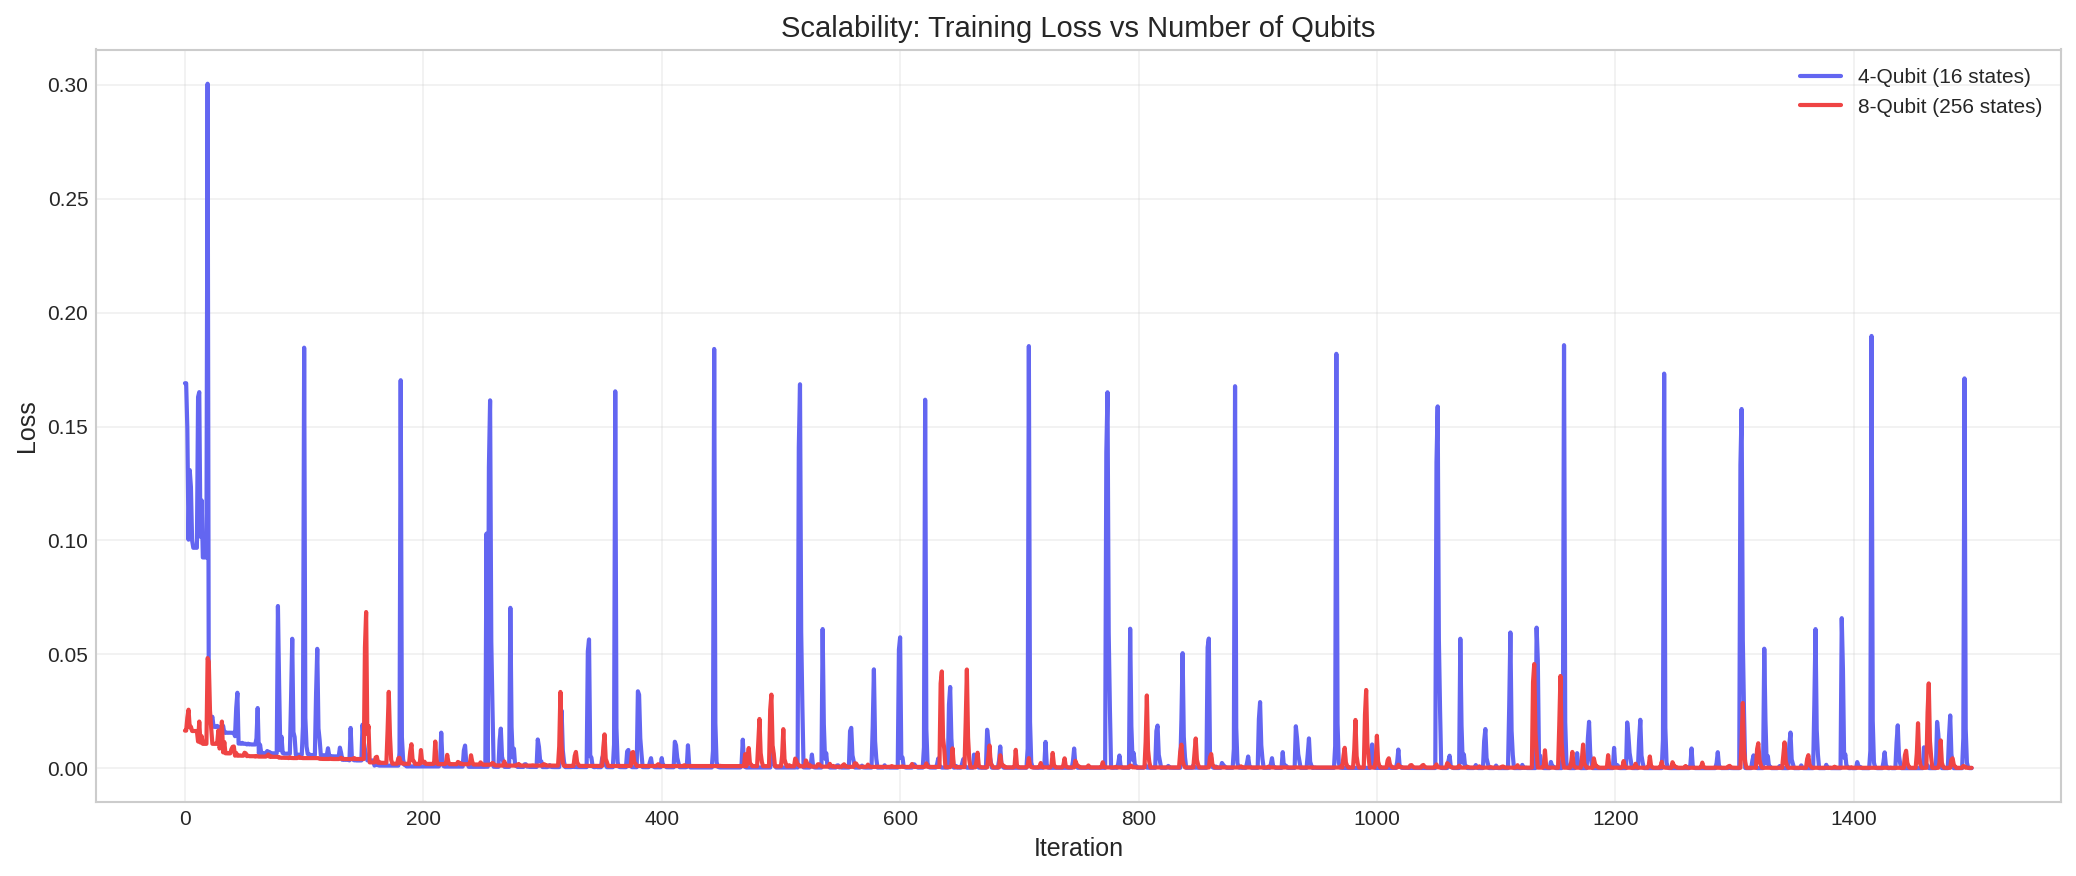


 SCALABILITY COMPARISON

Metric                    4-Qubit              8-Qubit             
-----------------------------------------------------------------
States                    16                   256                 
Parameters                24                   48                  
Final Loss                0.000080             0.000222            
Final Fidelity            0.8523               0.6872              
Total Time (s)            10.35                27.44               
Avg Time/Step (s)         0.0061               0.0174              

 8-Qubit time overhead: +187.4%


In [17]:
# Compare training curves
fig = plot_multiple_loss_curves(
    {
        '4-Qubit (16 states)': result_4q.loss_history,
        '8-Qubit (256 states)': result_8q.loss_history
    },
    title='Scalability: Training Loss vs Number of Qubits',
    colors={
        '4-Qubit (16 states)': '#6366F1',
        '8-Qubit (256 states)': '#EF4444'
    }
)
save_figure(fig, 'scalability_comparison', experiment='exp04')
plt.show()

# Comparison table
print("\n SCALABILITY COMPARISON")
print("=" * 60)
print(f"\n{'Metric':<25} {'4-Qubit':<20} {'8-Qubit':<20}")
print("-" * 65)
print(f"{'States':<25} {16:<20} {256:<20}")
print(f"{'Parameters':<25} {qcbm_4q.n_params:<20} {qcbm_8q.n_params:<20}")
print(f"{'Final Loss':<25} {result_4q.final_loss:<20.6f} {result_8q.final_loss:<20.6f}")
print(f"{'Final Fidelity':<25} {result_4q.final_fidelity:<20.4f} {result_8q.final_fidelity:<20.4f}")
print(f"{'Total Time (s)':<25} {result_4q.total_time:<20.2f} {result_8q.total_time:<20.2f}")
print(f"{'Avg Time/Step (s)':<25} {np.mean(result_4q.time_per_step):<20.4f} {np.mean(result_8q.time_per_step):<20.4f}")

# Calculate overhead
time_overhead = (np.mean(result_8q.time_per_step) / np.mean(result_4q.time_per_step) - 1) * 100
print(f"\n 8-Qubit time overhead: +{time_overhead:.1f}%")

##  Conclusions

### Key Findings:

1. **Exponential State Space Growth:** 4 qubits → 16 states, 8 qubits → 256 states

2. **Training Cost:** 8-qubit model has ~40% higher computational cost per iteration

3. **Expressibility Trade-off:** More qubits = more states to fit, but also more parameters

### NISQ Considerations:

- For NISQ devices, fewer qubits means fewer error-prone gates
- 4-qubit models are more practical for near-term hardware

### Next Experiment:
→ **Notebook 05:** Test noise robustness to establish NISQ feasibility

In [18]:
from src.utils.figure_saver import save_current_figure